In [1]:
%reload_ext autoreload
%autoreload 2


from simulate.models.BrainstemModel.params import Parameters as params
import nest
import numpy as np
from utils.manual_fixes_to_nest.connect import connect
from utils.log_utils import logger, tqdm
from utils.custom_sounds import Tone
import brian2 as b2
import brian2hears as b2h
from analyze.report import plot_sound
from utils.anf_utils import load_anf_response, ZI_COC_KEY, spikes_to_nestgen
import matplotlib.pyplot as plt
import numpy as np


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.8.0
 Built: Jul 24 2025 05:26:03

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

2026-02-27 12:31:18,250 [INFO ]  

>>>>> start execution
✅ Using local cochlea package from: /Users/francescodesantis/Documents/repos/sound_localization_model/external/cochlea-1



How to cite *cochlea*:

Rudnicki M. and Hemmert W. (2009—). Cochlea: inner ear models in
Python.  https://github.com/mrkrd/cochlea/

@Misc{Rudnicki2009-Cochlea,
  author       = {Rudnicki, M. and Hemmert, W.},
  title        = {Cochlea: inner ear models in Python},
  year         = {2009--},
  howpublished = {https://github.com/mrkrd/cochlea},
  url          = {https://github.com/mrkrd/cochlea},
}



In [7]:
nest.GetDefaults('iaf_cond_beta')['recordables']

('g_ex', 'g_in', 't_ref_remaining', 'V_m')

In [6]:
x =  ['C_m', 'g_L', 'E_L', 'V_reset', 'V_th', "t_ref", "E_ex", "tau_rise_ex", "tau_decay_ex", "E_in", "tau_rise_in", "tau_decay_in"]
print("default:")
for i in x:
    print(i, " = ", nest.GetDefaults('iaf_cond_beta')[i])

default:
C_m  =  250.0
g_L  =  16.6667
E_L  =  -70.0
V_reset  =  -60.0
V_th  =  -55.0
t_ref  =  2.0
E_ex  =  0.0
tau_rise_ex  =  0.2
tau_decay_ex  =  0.2
E_in  =  -85.0
tau_rise_in  =  2.0
tau_decay_in  =  2.0


In [15]:
P = params()
populations = ["SBC", "GBC", "MNTBC", "LNTBC", "LSO", "MSO", "SPN"]

all_params = {}

for pop in populations:
    all_params[pop] = {
        "C_m":          getattr(P.MEMB_CAPS, pop),
        "g_L":          getattr(P.G_LEAK, pop),
        "E_L":          getattr(P.E_L, pop),
        "V_m":          getattr(P.E_L, pop),
        "V_reset":      getattr(P.V_RESET, pop),
        "V_th":         getattr(P.V_TH, pop),
        "t_ref":        getattr(P.T_REF, pop),
        "E_ex":         getattr(P.EXC_REV, pop),
        "tau_rise_ex":  getattr(P.TAUS_EX_RISE, pop),
        "tau_decay_ex": getattr(P.TAUS_EX_DECAY, pop),
        "E_in":         getattr(P.INH_REV, pop),
        "tau_rise_in":  getattr(P.TAUS_IN_RISE, pop),
        "tau_decay_in": getattr(P.TAUS_IN_DECAY, pop),
    }

    print(f"\n{pop} parameters:")
    for key, value in all_params[pop].items():
        print(f"  {key}: {value}")


SBC parameters:
  C_m: 26.0
  g_L: 43.3
  E_L: -65.0
  V_m: -65.0
  V_reset: -67.0
  V_th: -45.0
  t_ref: 0.6
  E_ex: 0
  tau_rise_ex: 0.2
  tau_decay_ex: 0.5
  E_in: -75.0
  tau_rise_in: 2.0
  tau_decay_in: 2.0

GBC parameters:
  C_m: 13.0
  g_L: 86.6
  E_L: -65.0
  V_m: -65.0
  V_reset: -67.0
  V_th: -45.0
  t_ref: 0.6
  E_ex: 0
  tau_rise_ex: 0.2
  tau_decay_ex: 0.5
  E_in: -75.0
  tau_rise_in: 2.0
  tau_decay_in: 2.0

MNTBC parameters:
  C_m: 12.0
  g_L: 1.33
  E_L: -67.0
  V_m: -67.0
  V_reset: -69.0
  V_th: -45.0
  t_ref: 0.6
  E_ex: 0
  tau_rise_ex: 0.1
  tau_decay_ex: 0.35
  E_in: -75.0
  tau_rise_in: 2.0
  tau_decay_in: 2.0

LNTBC parameters:
  C_m: 12.0
  g_L: 1.33
  E_L: -60.0
  V_m: -60.0
  V_reset: -62.0
  V_th: -45.0
  t_ref: 0.6
  E_ex: 0
  tau_rise_ex: 0.25
  tau_decay_ex: 3.8
  E_in: -75.0
  tau_rise_in: 2.0
  tau_decay_in: 2.0

LSO parameters:
  C_m: 12.0
  g_L: 24
  E_L: -63.0
  V_m: -63.0
  V_reset: -65.0
  V_th: -45.0
  t_ref: 0.6
  E_ex: 0
  tau_rise_ex: 0.5
  ta

In [23]:
def make_pre_spike_times(base_times, num_inputs, delta=0.0):
    return [ [t + i * delta for t in base_times] for i in range(num_inputs) ] 

anf_colors = ["red", "blue", "green", "orange"]
y_anf_base = -70

In [41]:
def run_condition(input_spike_times_exc,
                  input_spike_times_inh,
                  weight_exc,
                  weight_inh,
                  delay_exc,
                  delay_inh,
                  post_params):

    nest.ResetKernel()
    nest.SetKernelStatus(P.CONFIG.NEST_KERNEL_PARAMS)

    # --- Create EXC inputs ---
    pres_exc = nest.Create(
        "spike_generator",
        len(input_spike_times_exc),
        params=[{"spike_times": st} for st in input_spike_times_exc]
    )

    # --- Create INH inputs ---
    pres_inh = nest.Create(
        "spike_generator",
        len(input_spike_times_inh),
        params=[{"spike_times": st} for st in input_spike_times_inh]
    )

    # --- post neuron ---
    post = nest.Create(
        "iaf_cond_beta",
        1,
        params=post_params
    )

    # --- Recorders ---
    sr = nest.Create("spike_recorder")
    mm = nest.Create(
        "multimeter",
        1,
        {"record_from": ["V_m", "g_ex", "g_in"], "record_to": "memory"}
    )

    nest.Connect(post, sr)
    nest.SetStatus(mm, {"interval": 0.01})
    nest.Connect(mm, post)

    # --- Connect EXC ---
    connect(
        pres_exc,
        post,
        conn_spec="x_to_one",
        syn_spec={"weight": weight_exc, "delay": delay_exc},
        num_sources=len(input_spike_times_exc),
    )

    # --- Connect INH ---
    connect(
        pres_inh,
        post,
        conn_spec="x_to_one",
        syn_spec={"weight": weight_inh, "delay": delay_inh},
        num_sources=len(input_spike_times_inh),
    )

    # --- Simulate ---
    nest.Simulate(10)

    # --- Retrieve data ---
    mm_data = nest.GetStatus(mm, keys="events")[0]
    times = mm_data["times"]
    V_m = mm_data["V_m"]
    g_ex = mm_data["g_ex"]
    g_in = mm_data["g_in"]

    E_ex = post_params["E_ex"]
    E_in = post_params["E_in"]

    I_ex = g_ex * (V_m - E_ex)
    I_in = g_in * (V_m - E_in)

    post_spikes = nest.GetStatus(sr, keys='events')[0]['times']

    # =========================
    # -------- PLOT -----------
    # =========================
    fig, ax = plt.subplots(3, figsize=(7, 6), sharex=True)

    # --- Conductances ---
    ax[0].plot(times, g_ex, label="g_ex", color='r')
    ax[0].plot(times, g_in, label="g_in", color='b')
    ax[0].set_ylabel("g (nS)")
    ax[0].legend()
    ax[0].grid(True)

    # --- Currents ---
    ax[1].plot(times, I_ex, label="I_ex", color='r')
    ax[1].plot(times, I_in, label="I_in", color='b')
    ax[1].set_ylabel("I (nA)")
    ax[1].legend()
    ax[1].grid(True)

    # --- Vm + Spikes ---
    ax[2].plot(times, V_m, color='k')
    ax[2].axhline(-45, linestyle='--', color='k')
    ax[2].set_ylabel("V_m (mV)")
    ax[2].grid(True)

    y_exc_base = -70
    for i, st in enumerate(input_spike_times_exc):
        ax[2].scatter(st, [y_exc_base - i] * len(st), marker="^", s=50, label=f"Exc {i+1}")

    y_inh_base = -75
    for i, st in enumerate(input_spike_times_inh):
        ax[2].scatter(st, [y_inh_base - i] * len(st), marker="v", s=50, label=f"Inh {i+1}")

    ax[2].scatter(post_spikes, [-60] * len(post_spikes), marker="*", color="g", s=70, label="POST")
    ax[2].set_xlabel("Time (ms)")

    plt.tight_layout()
    plt.show()


Feb 27 14:08:04 SimulationManager::set_status [Info]: 
    Temporal resolution changed from 0.1 to 0.01 ms.

Feb 27 14:08:04 NodeManager::prepare_nodes [Info]: 
    Preparing 129 nodes for simulation.

Feb 27 14:08:04 SimulationManager::start_updating_ [Info]: 
    Number of local nodes: 129
    Simulation time (ms): 10
    Number of OpenMP threads: 32
    Not using MPI

Feb 27 14:08:04 SimulationManager::run [Info]: 
    Simulation finished.


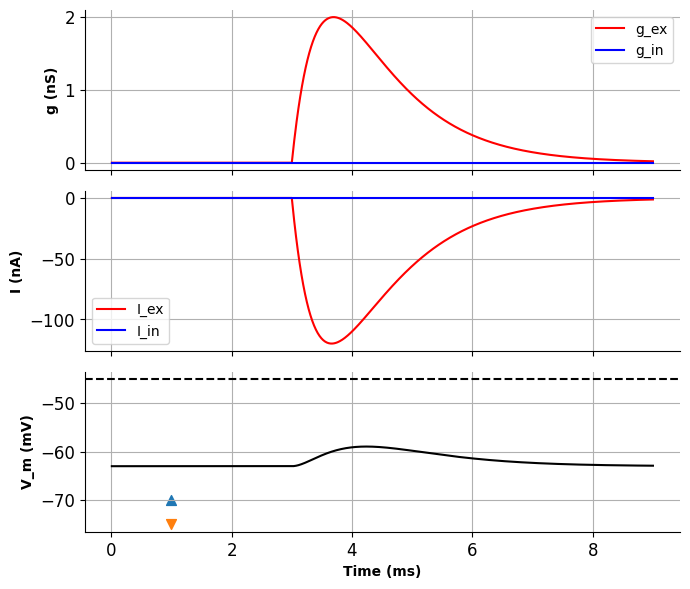

In [44]:
base_spike_times = [1]   # ms
num_pre_exc = 1
num_pre_inh = 0
delta =  0         # ms

exc_pre_times = make_pre_spike_times(
    base_spike_times,
    num_pre_exc,
    delta=delta
)

inh_pre_times = make_pre_spike_times(
    base_spike_times,
    num_pre_exc,
    delta=delta
)

run_condition(
    input_spike_times_exc=exc_pre_times,
    input_spike_times_inh=inh_pre_times,
    weight_exc=1,
    weight_inh=1,
    delay_exc=P.SYN_DELAYS.SBCs2LSO,
    delay_inh=P.SYN_DELAYS.MNTBCs2LSO + P.SYN_DELAYS.GBCs2MNTBCs + 0.5,
    post_params=all_params["LSO"]
)


## SINGLE FIBER PSTH

In [11]:
import os
import dill

addresses = [
'/Users/francescodesantis/Library/CloudStorage/OneDrive-PolitecnicodiMilano/work/sound_localization/sl_results/zilany/',
'/Users/francescodesantis/Documents/repos/sound_localization_model/results/',
'/g100_work/EIRI_E_POLIM2/desa/sound_localization_model/results/',
]

results_dir = addresses[1]

# List directory contents
items = os.listdir(results_dir)
items = sorted(items)
for i, item in enumerate(items):
    print(i, item)


0 .DS_Store
1 ANF_1200Hz_100rep.pic
2 ANF_16000Hz_100rep.pic
3 ANF_4000Hz_100rep.pic
4 ANF_500Hz_100rep.pic
5 tone_0.5kHz_59dB&Zilany&subject_0.pic
6 tone_0.5kHz_59dB&Zilany&subject_0_LNTB.pic
7 tone_0.5kHz_59dB&Zilany&subject_0_LSO_exc_leading.pic
8 tone_0.5kHz_59dB&Zilany&subject_0_LSO_inh_leading.pic
9 tone_0.5kHz_59dB&Zilany&subject_1.pic
10 tone_0.5kHz_59dB&Zilany&subject_2.pic
11 tone_0.5kHz_59dB&Zilany&subject_3.pic
12 tone_0.5kHz_59dB&Zilany&subject_4.pic
13 tone_1.2kHz_59dB&Zilany&subject_0.pic
14 zz_old


In [17]:
file_name = items[4]
print(f"Loading file: {file_name}")
result_path = results_dir + file_name

with open(result_path, "rb") as file:
    result = dill.load(file, ignore=True)

Loading file: ANF_500Hz_100rep.pic


In [13]:
sbc_file = results_dir + file_name.replace("ANF", "SBC")
gbc_file = results_dir + file_name.replace("ANF", "GBC")
mntbc_file = results_dir + file_name.replace("ANF", "MNTBC")
lntbc_file = results_dir + file_name.replace("ANF", "LNTBC")


num_repetitions = len(result)
num_anfs = len(result[0])

sim_time = 100.0  # ms

sbc_result = []
gbc_result = []
lntbc_result = []
mntbc_result = []

In [18]:
P = params()

sbc_params={
    "C_m": P.MEMB_CAPS.SBC,
    "g_L": P.G_LEAK.SBC,
    "E_L": P.E_L,
    "V_reset": P.V_reset,
    "V_th": P.V_TH.SBC,
    "t_ref": P.T_REF.SBC,
    "E_ex": P.EXC_REV,
    "tau_rise_ex": P.TAUS_EX_RISE.SBC,
    "tau_decay_ex": P.TAUS_EX_DECAY.SBC,
}
print("SBCs parameters:")
for key, value in sbc_params.items():
    print(f"{key}: {value}")

print("\nweight", P.SYN_WEIGHTS.ANFs2SBCs)


gbc_params={
    "C_m": P.MEMB_CAPS.GBC,
    "g_L": P.G_LEAK.GBC,
    "E_L": P.E_L,
    "V_reset": P.V_reset,
    "V_th": P.V_TH.GBC,
    "V_m": P.E_L,
    "t_ref": P.T_REF.GBC,
    "E_ex": P.EXC_REV,
    "tau_rise_ex": P.TAUS_EX_RISE.GBC,
    "tau_decay_ex": P.TAUS_EX_DECAY.GBC,
}
print("\n\nGBCs parameters:")
for key, value in gbc_params.items():
    print(f"{key}: {value}")

print("\nweight", P.SYN_WEIGHTS.ANFs2GBCs)

mntbc_params={
    "C_m": P.MEMB_CAPS.MNTBC,
    "g_L": P.G_LEAK.MNTBC,
    "E_L": P.E_L,
    "V_reset": P.V_reset,
    "V_th": P.V_TH.MNTBC,
    "V_m": P.E_L,
    "t_ref": P.T_REF.MNTBC,
    "E_ex": P.EXC_REV,
    "tau_rise_ex": P.TAUS_EX_RISE.MNTBC,
    "tau_decay_ex": P.TAUS_EX_DECAY.MNTBC,
}
print("\n\nMNTBCs parameters:")
for key, value in mntbc_params.items():
    print(f"{key}: {value}")

print("\nweight", P.SYN_WEIGHTS.GBCs2MNTBCs)


lntbc_params={
    "C_m": P.MEMB_CAPS.LNTBC,
    "g_L": P.G_LEAK.LNTBC,
    "E_L": P.E_L,
    "V_reset": P.V_reset,
    "V_th": P.V_TH.LNTBC,
    "V_m": P.E_L,
    "t_ref": P.T_REF.LNTBC,
    "E_ex": P.EXC_REV,
    "tau_rise_ex": P.TAUS_EX_RISE.LNTBC,
    "tau_decay_ex": P.TAUS_EX_DECAY.LNTBC,
}
print("\n\nLNTBCs parameters:")
for key, value in lntbc_params.items():
    print(f"{key}: {value}")

print("\nweight", P.SYN_WEIGHTS.GBCs2LNTBCs)

SBCs parameters:
C_m: 26.0
g_L: 43.3
E_L: -65.0
V_reset: -67.0
V_th: -45.0
t_ref: 0.6
E_ex: 0.0
tau_rise_ex: 0.2
tau_decay_ex: 0.5

weight 16.0


GBCs parameters:
C_m: 13.0
g_L: 86.6
E_L: -65.0
V_reset: -67.0
V_th: -45.0
V_m: -65.0
t_ref: 0.6
E_ex: 0.0
tau_rise_ex: 0.2
tau_decay_ex: 0.5

weight 7.0


MNTBCs parameters:
C_m: 20.0
g_L: 4
E_L: -65.0
V_reset: -67.0
V_th: -45.0
V_m: -65.0
t_ref: 0.6
E_ex: 0.0
tau_rise_ex: 0.2
tau_decay_ex: 0.2

weight 30.0


LNTBCs parameters:
C_m: 20.0
g_L: 5
E_L: -65.0
V_reset: -67.0
V_th: -45.0
V_m: -65.0
t_ref: 0.6
E_ex: 0.0
tau_rise_ex: 0.2
tau_decay_ex: 0.2

weight 30.0


In [19]:
import nest
import numpy as np
import pandas as pd
from utils.log_utils import logger, tqdm

nest.set_verbosity("M_ERROR")
for r in tqdm(range(num_repetitions), desc="reps"):

    #print(f"Running repetition {r+1}/{num_repetitions}")

    # --------------------------------------------------
    # Reset kernel
    # --------------------------------------------------
    nest.ResetKernel()
    nest.SetKernelStatus(P.CONFIG.NEST_KERNEL_PARAMS)

    # --------------------------------------------------
    # Prepare ANF spike times (s → ms)
    # --------------------------------------------------
    anf_params = [
        {"spike_times": [t * 1000.0 for t in result[r].iloc[i]]}
        for i in range(num_anfs)
    ]

    # --------------------------------------------------
    # Create ANFs
    # --------------------------------------------------
    anf = nest.Create(
        "spike_generator",
        num_anfs,
        params=anf_params
    )

    # ==================================================
    # SBC POPULATION
    # ==================================================
    sbc = nest.Create(
        "iaf_cond_beta",
        P.POP_NUM.n_SBCs,
        params=sbc_params          # your SBC params
    )
    sbc_ids = np.array(sbc)

    sr_sbc = nest.Create("spike_recorder")
    nest.Connect(sbc, sr_sbc, "all_to_all")

    connect(
        anf,
        sbc,
        conn_spec="x_to_one",
        syn_spec={"weight": P.SYN_WEIGHTS.ANFs2SBCs, "delay": P.SYN_DELAYS.ANFs2SBCs},
        num_sources=P.POP_CONV.ANFs2SBCs,
    )

    # ==================================================
    # GBC POPULATION
    # ==================================================
    gbc = nest.Create(
        "iaf_cond_beta",
        P.POP_NUM.n_GBCs,
        params=gbc_params      # GBC-specific params
    )
    gbc_ids = np.array(gbc)

    sr_gbc = nest.Create("spike_recorder")
    nest.Connect(gbc, sr_gbc, "all_to_all")

    connect(
        anf,
        sbc,
        conn_spec="x_to_one",
        syn_spec={"weight": P.SYN_WEIGHTS.ANFs2GBCs, "delay": P.SYN_DELAYS.ANFs2GBCs},
        num_sources=P.POP_CONV.ANFs2GBCs,
    )

    # ==================================================
    # MNTBC POPULATION
    # ==================================================
    mntbc = nest.Create(
        "iaf_cond_beta",
        P.POP_NUM.n_MNTBCs,
        params=mntbc_params          # your MNTBC params
    )
    mntbc_ids = np.array(mntbc)

    sr_mntbc = nest.Create("spike_recorder")
    nest.Connect(mntbc, sr_mntbc, "all_to_all")

    connect(
        gbc,
        mntbc,
        conn_spec="x_to_one",
        syn_spec={"weight": P.SYN_WEIGHTS.GBCs2MNTBCs, "delay": P.SYN_DELAYS.GBCs2MNTBCs},
        num_sources=P.POP_CONV.GBCs2MNTBCs,
    )

    # ==================================================
    # LNTBC POPULATION
    # ==================================================
    lntbc = nest.Create(
        "iaf_cond_beta",
        P.POP_NUM.n_LNTBCs,
        params=lntbc_params          # your LNTBC params
    )
    lntbc_ids = np.array(lntbc)

    sr_lntbc = nest.Create("spike_recorder")
    nest.Connect(lntbc, sr_lntbc, "all_to_all")

    connect(
        gbc,
        lntbc,
        conn_spec="x_to_one",
        syn_spec={"weight": P.SYN_WEIGHTS.GBCs2LNTBCs, "delay": P.SYN_DELAYS.GBCs2LNTBCs},
        num_sources=P.POP_CONV.GBCs2LNTBCs,
    )


    # --------------------------------------------------
    # Simulate
    # --------------------------------------------------
    nest.Simulate(sim_time)

    # ==================================================
    # COLLECT SBC SPIKES
    # ==================================================
    events = nest.GetStatus(sr_sbc, "events")[0]
    sbc_spikes = [[] for _ in range(P.POP_NUM.n_SBCs)]
    sbc_id2idx = {gid: i for i, gid in enumerate(sbc_ids)}

    for gid, t_ms in zip(events["senders"], events["times"]):
        sbc_spikes[sbc_id2idx[gid]].append(t_ms * 1e-3)

    sbc_result.append(
        pd.Series(sbc_spikes, name="spikes", dtype=object)
    )

    # ==================================================
    # COLLECT GBC SPIKES
    # ==================================================
    events = nest.GetStatus(sr_gbc, "events")[0]
    gbc_spikes = [[] for _ in range(P.POP_NUM.n_GBCs)]
    gbc_id2idx = {gid: i for i, gid in enumerate(gbc_ids)}

    for gid, t_ms in zip(events["senders"], events["times"]):
        gbc_spikes[gbc_id2idx[gid]].append(t_ms * 1e-3)

    gbc_result.append(
        pd.Series(gbc_spikes, name="spikes", dtype=object)
    )

    # ==================================================
    # COLLECT LNTBC SPIKES
    # ==================================================
    events = nest.GetStatus(sr_lntbc, "events")[0]
    lntbc_spikes = [[] for _ in range(P.POP_NUM.n_LNTBCs)]
    lntbc_id2idx = {gid: i for i, gid in enumerate(lntbc_ids)}

    for gid, t_ms in zip(events["senders"], events["times"]):
        lntbc_spikes[lntbc_id2idx[gid]].append(t_ms * 1e-3)

    lntbc_result.append(
        pd.Series(lntbc_spikes, name="spikes", dtype=object)
    )

    # ==================================================
    # COLLECT MNTBC SPIKES
    # ==================================================
    events = nest.GetStatus(sr_mntbc, "events")[0]
    mntbc_spikes = [[] for _ in range(P.POP_NUM.n_MNTBCs)]
    mntbc_id2idx = {gid: i for i, gid in enumerate(mntbc_ids)}      
    for gid, t_ms in zip(events["senders"], events["times"]):
        mntbc_spikes[mntbc_id2idx[gid]].append(t_ms * 1e-3)

    mntbc_result.append(
        pd.Series(mntbc_spikes, name="spikes", dtype=object)
    )



# --------------------------------------------------
# Final outputs
# --------------------------------------------------
# sbc_result[r] → same format as result[r]
# gbc_result[r] → same format as result[r]
# --------------------------------------------------

    # --------------------------------------------------
# Save SBC spikes
# --------------------------------------------------
print(f"Saving SBC spikes to: {sbc_file}")
with open(sbc_file, "wb") as f:
    dill.dump(sbc_result, f)

# --------------------------------------------------
# Save GBC spikes
# --------------------------------------------------
print(f"Saving GBC spikes to: {gbc_file}")
with open(gbc_file, "wb") as f:
    dill.dump(gbc_result, f)

# --------------------------------------------------
# Save LNTBC spikes
# --------------------------------------------------
print(f"Saving LNTBC spikes to: {lntbc_file}")
with open(lntbc_file, "wb") as f:
    dill.dump(lntbc_result, f)

# --------------------------------------------------
# Save MNTBC spikes
# --------------------------------------------------
print(f"Saving MNTBC spikes to: {mntbc_file}")
with open(mntbc_file, "wb") as f:
    dill.dump(mntbc_result, f)

reps: 100%|██████████| 100/100 [37:30<00:00, 22.50s/it]


Saving SBC spikes to: /Users/francescodesantis/Documents/repos/sound_localization_model/results/SBC_500Hz_100rep.pic
Saving GBC spikes to: /Users/francescodesantis/Documents/repos/sound_localization_model/results/GBC_500Hz_100rep.pic
Saving LNTBC spikes to: /Users/francescodesantis/Documents/repos/sound_localization_model/results/LNTBC_500Hz_100rep.pic
Saving MNTBC spikes to: /Users/francescodesantis/Documents/repos/sound_localization_model/results/MNTBC_500Hz_100rep.pic


In [16]:
from analyze.report import plot_single_neuron_psth

plot_single_neuron_psth(
  spikes_file=result,
  target_cf_hz=500,
  xlim=(0, 100),
  ylim=(0,3000),
  n_neighbors=0,
  bin_size=0.2,
  color = 'b',
  figsize=(7,3)
)

Selected neurons:
  Target CF      : 500.0 Hz
  Center idx     : 704
  Index range    : [704, 704]
  CF range [Hz]  : 500.2 – 500.2
  # neurons used : 1


RuntimeError: No spikes found for selected neurons.

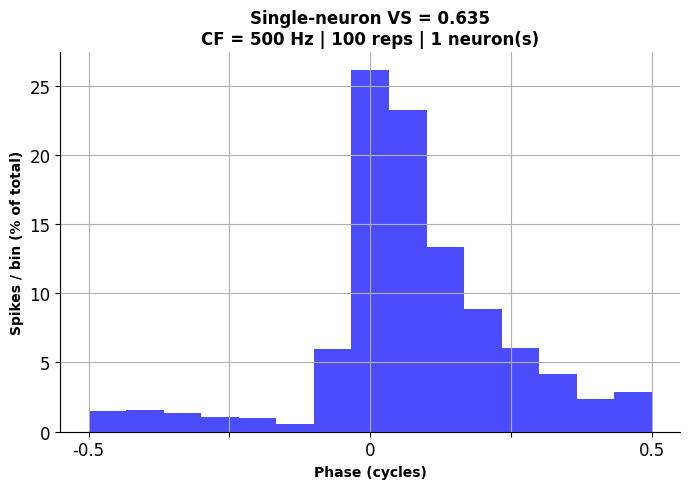

(0.6348393656107721, <Figure size 700x500 with 1 Axes>)

In [ ]:
from analyze.report import calculate_single_neuron_vector_strength

calculate_single_neuron_vector_strength(
    spikes_file=result, 
    target_cf_hz=500,
    n_neighbors=0,
    center_at_peak=True,
    n_bins=15
    )

In [20]:
# List directory contents
items = os.listdir(results_dir)
items = sorted(items)
for i, item in enumerate(items):
    print(i, item)

0 .DS_Store
1 ANF_1200Hz_100rep.pic
2 ANF_16000Hz_100rep.pic
3 ANF_4000Hz_100rep.pic
4 ANF_500Hz_100rep.pic
5 GBC_500Hz_100rep.pic
6 LNTBC_500Hz_100rep.pic
7 MNTBC_500Hz_100rep.pic
8 SBC_500Hz_100rep.pic
9 tone_0.5kHz_59dB&Zilany&subject_0.pic
10 tone_0.5kHz_59dB&Zilany&subject_0_LNTB.pic
11 tone_0.5kHz_59dB&Zilany&subject_0_LSO_exc_leading.pic
12 tone_0.5kHz_59dB&Zilany&subject_0_LSO_inh_leading.pic
13 tone_0.5kHz_59dB&Zilany&subject_1.pic
14 tone_0.5kHz_59dB&Zilany&subject_2.pic
15 tone_0.5kHz_59dB&Zilany&subject_3.pic
16 tone_0.5kHz_59dB&Zilany&subject_4.pic
17 tone_1.2kHz_59dB&Zilany&subject_0.pic
18 zz_old


In [25]:
file_name = items[8]
print(f"Loading file: {file_name}")
result_path = results_dir + file_name

with open(result_path, "rb") as file:
    result = dill.load(file, ignore=True)

Loading file: SBC_500Hz_100rep.pic


Selected neurons:
  Target CF      : 500.0 Hz
  Center idx     : 5475
  Index range    : [5475, 5475]
  CF range [Hz]  : 500.0 – 500.0
  # neurons used : 1


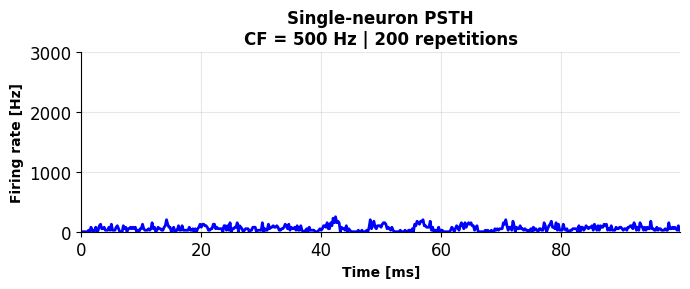

In [26]:
from analyze.report import plot_single_neuron_psth

plot_single_neuron_psth(
  spikes_file=result,
  target_cf_hz=500,
  ylim=(0, 3000),
  n_neighbors=0,
  bin_size=0.2,
  color = 'b',
  figsize=(7,3)
)